<a href="https://colab.research.google.com/github/KetsiaAdairse/KetsiaAdairse/blob/main/Chalenge_Telecom_segundaparte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import json

# 1. Carregar o arquivo JSON
with open('TelecomX_Data.json', 'r') as f:
    data = json.load(f)

# 2. "Achatar" (flatten) os dados para criar uma tabela limpa
df = pd.json_normalize(data)

# Visualizar as primeiras linhas e as novas colunas
print(df.columns)
df.head()

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [4]:
# 'coerce' transforma o que não for número (espaços vazios) em NaN (nulo)
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

In [5]:
# Verificar quantos nulos existem em cada coluna
print(df.isnull().sum())

# Opção A: Remover linhas com qualquer valor nulo (mais seguro)
df_limpo = df.dropna().copy()

# Opção B: Preencher nulos com zero (se fizer sentido para o negócio)
# df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64


In [6]:
# Transformando Yes/No em 1/0 para facilitar cálculos matemáticos
colunas_binarias = ['Churn', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService']

for col in colunas_binarias:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

In [7]:
def limpar_dados_telecom(dataframe):
    # 1. Remover IDs de clientes (não servem para análise estatística)
    if 'customerID' in dataframe.columns:
        dataframe = dataframe.drop(columns=['customerID'])

    # 2. Corrigir tipos numéricos
    dataframe['account.Charges.Total'] = pd.to_numeric(dataframe['account.Charges.Total'], errors='coerce')

    # 3. Remover linhas onde o Total é nulo (geralmente clientes com 0 meses de casa)
    dataframe = dataframe.dropna(subset=['account.Charges.Total'])

    # 4. Remover duplicatas
    dataframe = dataframe.drop_duplicates()

    return dataframe

# Aplicando a limpeza
df_final = limpar_dados_telecom(df)
print(f"Dados originais: {len(df)} | Dados após limpeza: {len(df_final)}")

Dados originais: 7267 | Dados após limpeza: 7234


In [9]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carregar e Achatar
with open('TelecomX_Data.json', 'r') as f:
    data = json.load(f)
df = pd.json_normalize(data)

# 2. Limpeza Essencial
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df = df.dropna(subset=['account.Charges.Total'])

# 3. Transformar 'Yes'/'No' em 1/0 para a correlação
# Criamos uma cópia apenas com as colunas que queremos analisar
df_analise = df.copy()
colunas_binarias = ['Churn', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService', 'account.PaperlessBilling']

for col in colunas_binarias:
    df_analise[col] = df_analise[col].map({'Yes': 1, 'No': 0})

# 4. Transformar o tipo de Internet em números (0: No, 1: DSL, 2: Fiber)
df_analise['internet.InternetService'] = df_analise['internet.InternetService'].map({'No': 0, 'DSL': 1, 'Fiber optic': 2})

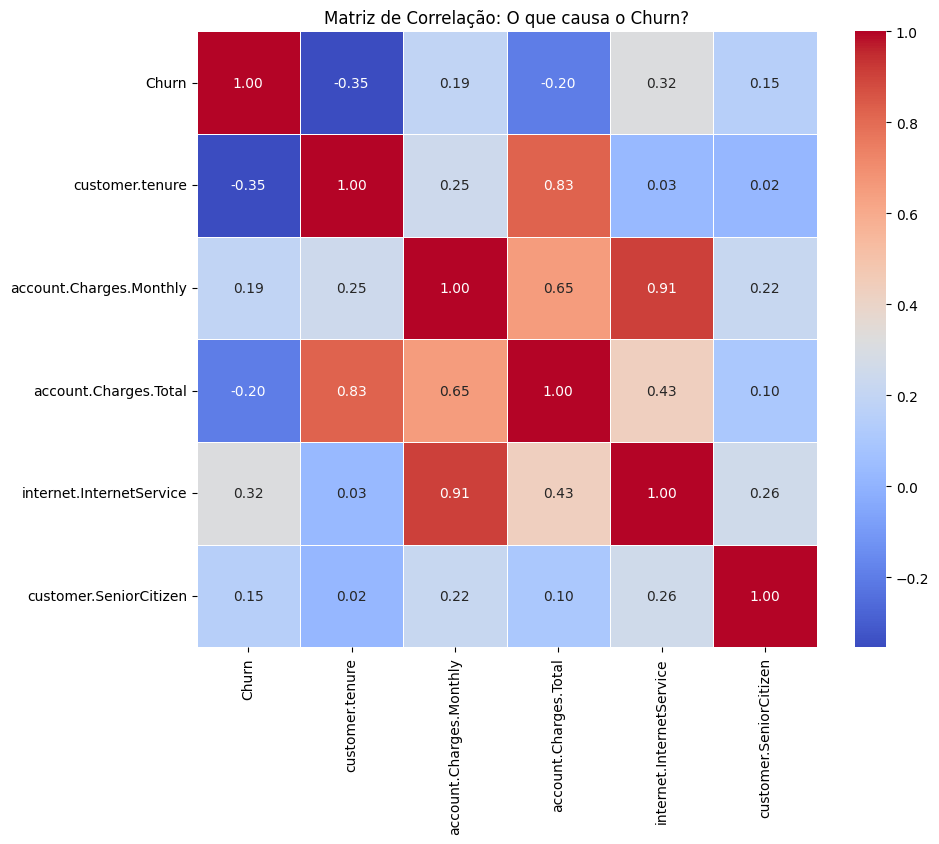

In [10]:
# Selecionar apenas colunas numéricas para a correlação
corr = df_analise[['Churn', 'customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'internet.InternetService', 'customer.SeniorCitizen']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação: O que causa o Churn?')
plt.show()

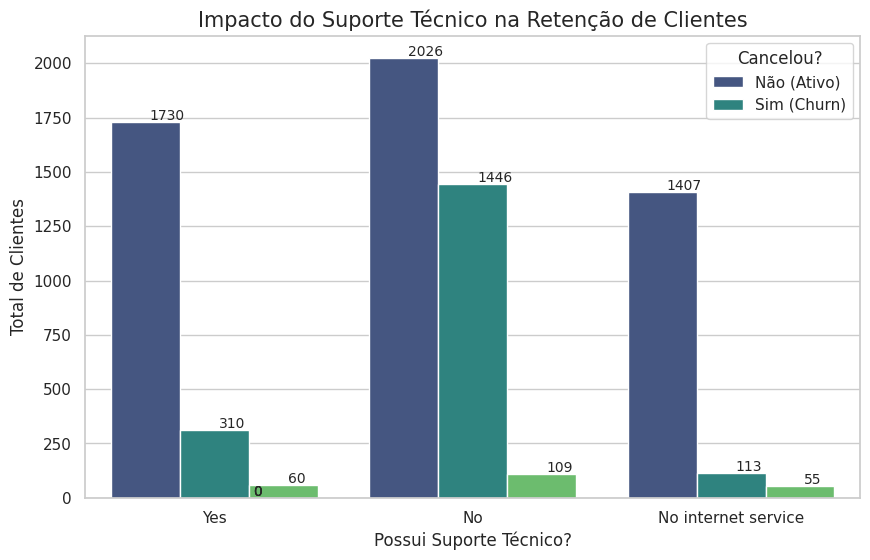

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definindo o estilo para combinar com um projeto profissional
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Criando o gráfico de barras comparativo
ax = sns.countplot(x='internet.TechSupport', hue='Churn', data=df, palette='viridis')

# Adicionando títulos e legendas
plt.title('Impacto do Suporte Técnico na Retenção de Clientes', fontsize=15)
plt.xlabel('Possui Suporte Técnico?', fontsize=12)
plt.ylabel('Total de Clientes', fontsize=12)
plt.legend(title='Cancelou?', labels=['Não (Ativo)', 'Sim (Churn)'])

# Adicionando os valores em cima das barras para facilitar a leitura
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.15, p.get_height() + 10), fontsize=10)

plt.show()